# Benchmark model performance

This notebooks benchmarks the available predictive models on sequence data.

In [1]:
import os

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from Bio.SeqUtils import IUPACData
from scipy import stats
from sklearn import metrics

from tcr_antigen_prediction.models import TCRContactMapPredictor

In [2]:
with h5py.File('data/processed/sequences.h5') as fh:
    cdr_1as = fh['cdr_1a'][:]
    cdr_2as = fh['cdr_2a'][:]
    cdr_3as = fh['cdr_3a'][:]
    cdr_1bs = fh['cdr_1b'][:]
    cdr_2bs = fh['cdr_2b'][:]
    cdr_3bs = fh['cdr_3b'][:]
    peptides = fh['peptide'][:]
    mhcs = fh['mhc_pseudo_sequence'][:]

    folds = fh['fold'][:]
    labels = fh['label'][:]

In [3]:
predictions = []

for fold_num in range(1, 5 + 1):
    print('Fold:', fold_num)
    hold_out_indicies = np.where(folds == fold_num)[0]

    for model_path in 'models/TCRContactMapPredictor', 'models/TCRContactMapPredictor_sequence_only':
        print('Loading model:', model_path)
        model = TCRContactMapPredictor()
        model.load_state_dict(
            torch.load(
                os.path.join(model_path, f'model_{fold_num}.pt'),
                map_location=torch.device('cpu'),
                weights_only=True,
            )
        )

        print('Making predictions')
        model.eval()

        prediction = model(
            torch.tensor(cdr_1as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_2as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_3as[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_1bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_2bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(cdr_3bs[hold_out_indicies], dtype=torch.float32),
            torch.tensor(peptides[hold_out_indicies], dtype=torch.float32),
            torch.tensor(mhcs[hold_out_indicies], dtype=torch.float32),
        )

        model_name = os.path.basename(model_path)

        predictions.append(
            pd.DataFrame(
                {
                    'index': hold_out_indicies,
                    'fold': [fold_num for _ in range(len(hold_out_indicies))],
                    'model_name': [model_name for _ in range(len(hold_out_indicies))],
                    'label': labels[hold_out_indicies],
                    'prediction': prediction.squeeze(-1).detach().cpu().numpy(),
                }
            )
        )

predictions = pd.concat(predictions)

Fold: 1
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 2
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 3
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 4
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions
Fold: 5
Loading model: models/TCRContactMapPredictor
Making predictions
Loading model: models/TCRContactMapPredictor_sequence_only
Making predictions


## ROC

In [4]:
roc_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.roc_curve(group['label'], group['prediction']),
    include_groups=False,
)
roc_results.name = 'roc_curve'
roc_results = roc_results.reset_index()

In [5]:
roc_results[['fpr', 'tpr', 'threshold']] = roc_results['roc_curve'].apply(pd.Series)

In [6]:
roc_results['roc_auc'] = roc_results.apply(lambda row: metrics.auc(row['fpr'], row['tpr']), axis=1)

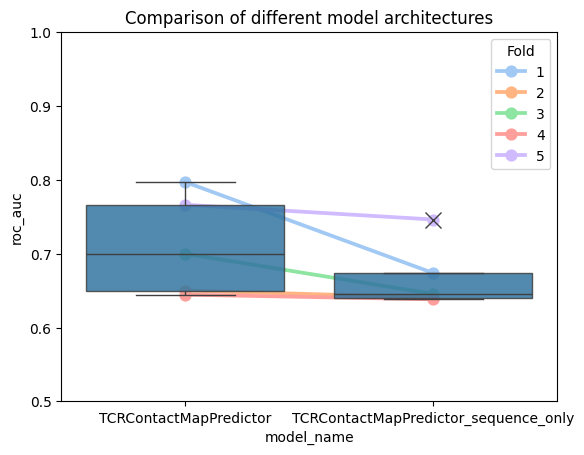

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.711459,0.699872,0.068328
TCRContactMapPredictor_sequence_only,0.668781,0.645400,0.045501


In [7]:
plt.title('Comparison of different model architectures')
plt.ylim([0.5, 1.0])

sns.pointplot(roc_results, x='model_name', y='roc_auc', hue='fold', palette='pastel')
sns.boxplot(
    roc_results,
    x='model_name',
    y='roc_auc',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

roc_results.groupby('model_name')['roc_auc'].agg(['mean', 'median', 'std'])

In [8]:
stats.wilcoxon(
    roc_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['roc_auc'],
    roc_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['roc_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=15.0, pvalue=0.03125)

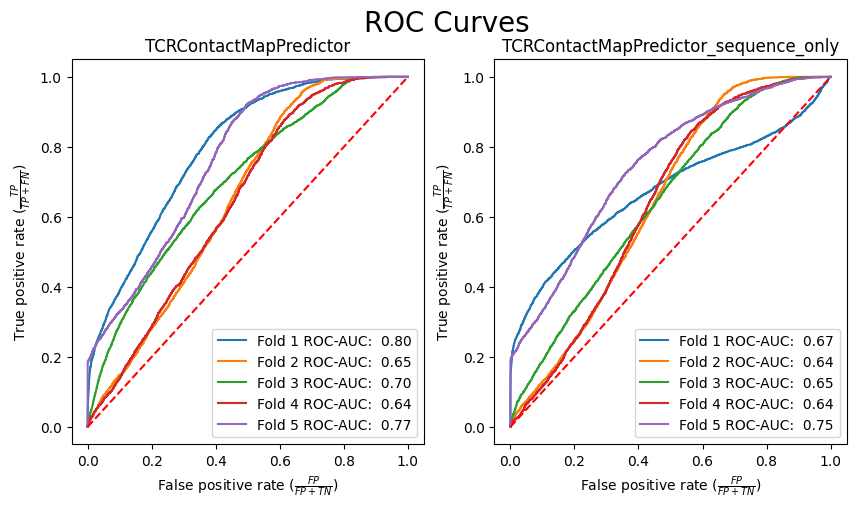

In [9]:
model_groups = roc_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('ROC Curves', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]
        group = fold_group.explode(['tpr', 'fpr'])

        axes[i].plot(group['fpr'], group['tpr'], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
    axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

In [10]:
model_groups = roc_results.groupby('model_name')

fpr_interp = np.linspace(0, 1, 100)
tpr_interp = {}

for model_name, model_group in model_groups:
    tpr_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['tpr', 'fpr'])

        tpr_interp[model_name][fold] = np.interp(fpr_interp, group['fpr'].apply(float), group['tpr'].apply(float))

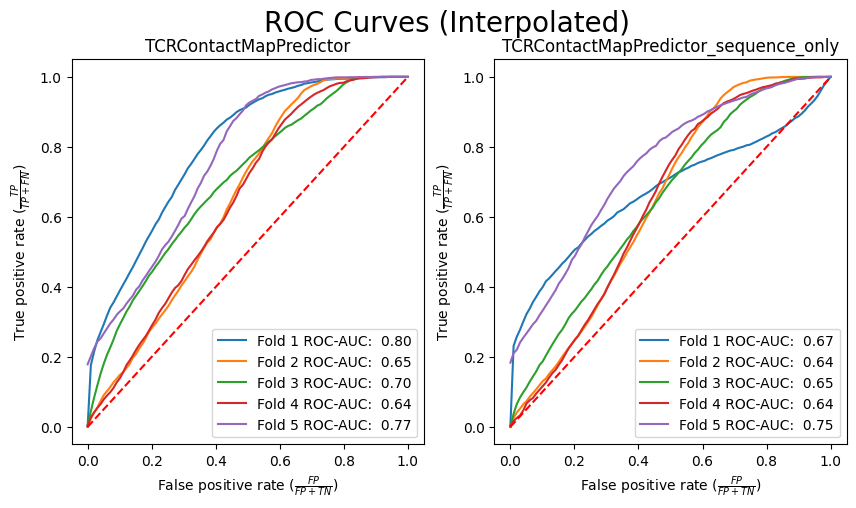

In [11]:
model_groups = roc_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('ROC Curves (Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['roc_auc'].to_numpy()[0]

        axes[i].plot(fpr_interp, tpr_interp[model_name][fold], label=f'Fold {fold} ROC-AUC: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].set_xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
    axes[i].set_ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
    axes[i].plot([0, 1], [0, 1], 'r--')
    axes[i].legend()

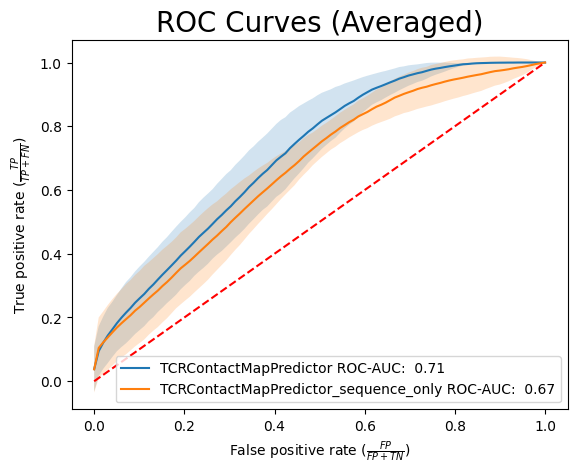

In [12]:
plt.title('ROC Curves (Averaged)', fontsize=20)

for model_name, _ in roc_results.groupby('model_name'):
    tpr_mean = np.mean(np.array(list(tpr_interp[model_name].values())).T, axis=1)
    tpr_std = np.std(np.array(list(tpr_interp[model_name].values())).T, axis=1)

    roc_auc = metrics.auc(fpr_interp, tpr_mean)

    plt.plot(fpr_interp, tpr_mean, label=f'{model_name} ROC-AUC: {roc_auc: .2f}')
    plt.fill_between(fpr_interp, tpr_mean - tpr_std, tpr_mean + tpr_std, alpha=0.2)

plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel(r'False positive rate ($\frac{FP}{FP + TN}$)')
plt.ylabel(r'True positive rate ($\frac{TP}{TP + FN}$)')
plt.legend()

plt.show()

## Precision-Recall

In [13]:
pr_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results.name = 'pr_curve'
pr_results = pr_results.reset_index()

In [14]:
pr_results[['precision', 'recall', 'threshold']] = pr_results['pr_curve'].apply(pd.Series)

In [15]:
pr_results['pr_auc'] = pr_results.apply(lambda row: metrics.auc(row['recall'], row['precision']), axis=1)

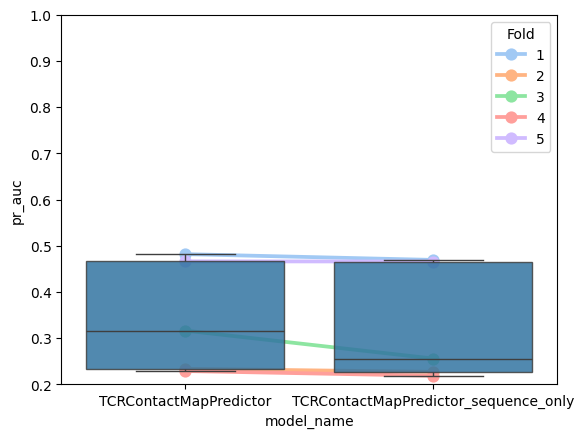

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.345571,0.316539,0.122627
TCRContactMapPredictor_sequence_only,0.327543,0.256017,0.128773


In [16]:
plt.ylim([0.2, 1.0])

sns.pointplot(pr_results, x='model_name', y='pr_auc', hue='fold', palette='pastel')
sns.boxplot(
    pr_results,
    x='model_name',
    y='pr_auc',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

pr_results.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])

In [17]:
stats.wilcoxon(
    pr_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['pr_auc'],
    pr_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['pr_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=15.0, pvalue=0.03125)

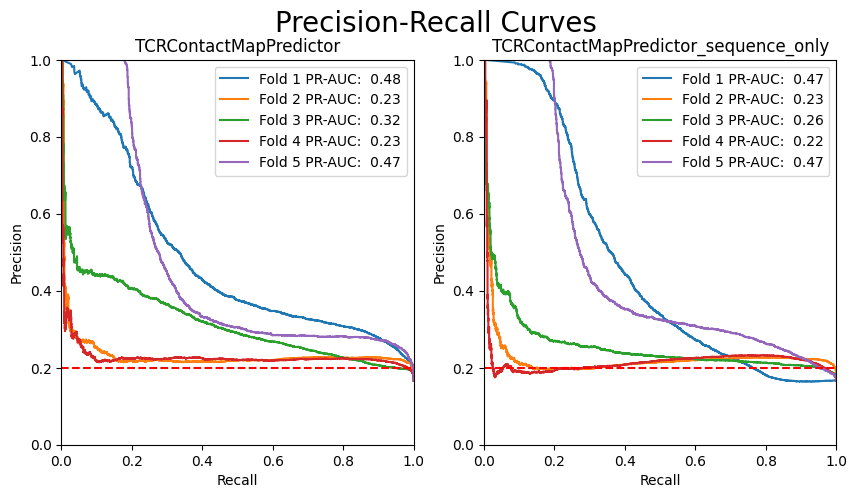

In [18]:
model_groups = pr_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

In [19]:
model_groups = pr_results.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

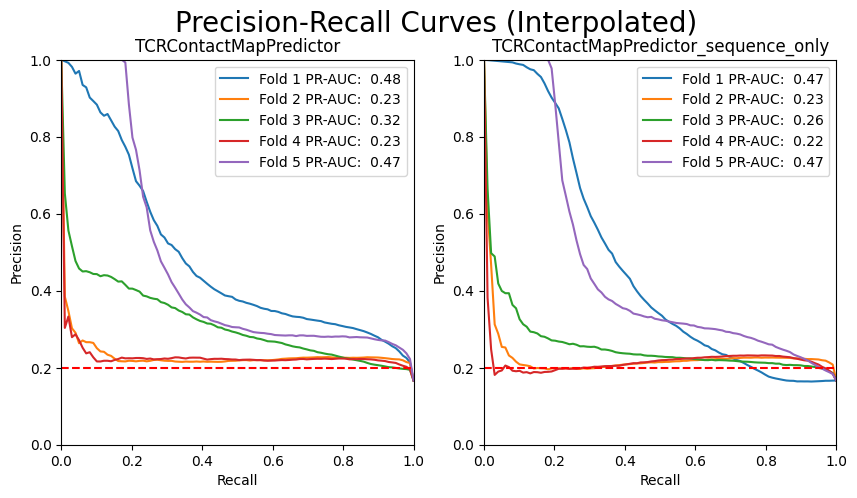

In [20]:
model_groups = pr_results.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [1 / 5, 1 / 5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0, 1])
    axes[i].legend()

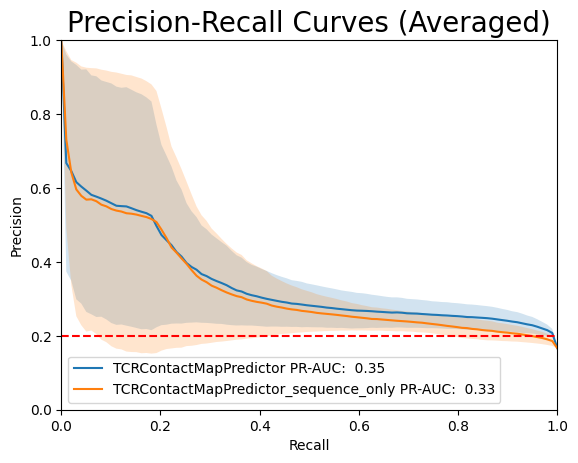

In [21]:
plt.title('Precision-Recall Curves (Averaged)', fontsize=20)

for model_name, _ in pr_results.groupby('model_name'):
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.plot([0, 1], [1 / 5, 1 / 5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.legend()

plt.show()

### Balancing classes

In [22]:
def down_sample_group(group: pd.DataFrame, random_state: int | np.random.Generator | None = None) -> pd.DataFrame:
    positives = group[group['label'] == 1]
    negatives = group[group['label'] == 0]

    num_positives = len(positives)
    num_negatives = len(negatives)

    if num_positives > num_negatives:
        return pd.concat([positives.sample(num_negatives, random_state=random_state), negatives])

    if num_positives < num_negatives:
        return pd.concat([positives, negatives.sample(num_positives, random_state=random_state)])

    return group


rng = np.random.default_rng(123)
balanced_predictions = (
    predictions.groupby(['model_name', 'fold'])
    .apply(
        down_sample_group,
        random_state=rng,
        include_groups=False,
    )
    .reset_index()
)

In [23]:
pr_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda group: metrics.precision_recall_curve(group['label'], group['prediction']),
    include_groups=False,
)
pr_results_balanced.name = 'pr_curve'
pr_results_balanced = pr_results_balanced.reset_index()

In [24]:
pr_results_balanced[['precision', 'recall', 'threshold']] = pr_results_balanced['pr_curve'].apply(pd.Series)

In [25]:
pr_results_balanced['pr_auc'] = pr_results_balanced.apply(
    lambda row: metrics.auc(row['recall'], row['precision']), axis=1
)

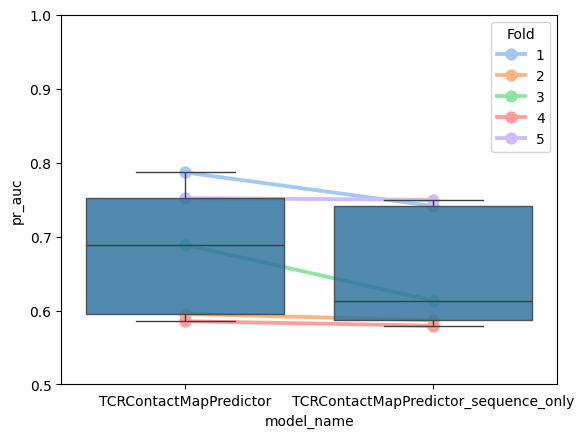

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.681713,0.688970,0.090510
TCRContactMapPredictor_sequence_only,0.654176,0.613315,0.084406


In [26]:
plt.ylim([0.5, 1.0])

sns.pointplot(pr_results_balanced, x='model_name', y='pr_auc', hue='fold', palette='pastel')
sns.boxplot(
    pr_results_balanced,
    x='model_name',
    y='pr_auc',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

pr_results_balanced.groupby('model_name')['pr_auc'].agg(['mean', 'median', 'std'])

In [27]:
stats.wilcoxon(
    pr_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['pr_auc'],
    pr_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['pr_auc'],
    alternative='greater',
)

WilcoxonResult(statistic=15.0, pvalue=0.03125)

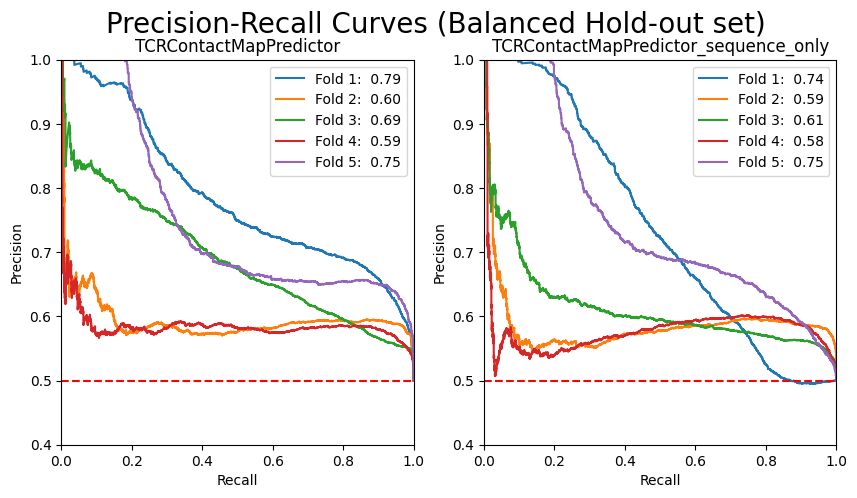

In [28]:
model_groups = pr_results_balanced.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        roc_auc = fold_group['pr_auc'].to_numpy()[0]
        group = fold_group.explode(['recall', 'precision'])

        axes[i].plot(group['recall'], group['precision'], label=f'Fold {fold}: {roc_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

In [29]:
model_groups = pr_results_balanced.groupby('model_name')

recall_interp = np.linspace(0, 1, 100)
precision_interp = {}

for model_name, model_group in model_groups:
    precision_interp[model_name] = {}
    for fold, fold_group in model_group.groupby('fold'):
        group = fold_group.explode(['recall', 'precision'])

        precision_interp[model_name][fold] = np.interp(
            recall_interp,
            group['recall'].apply(float)[::-1],
            group['precision'].apply(float)[::-1],
        )

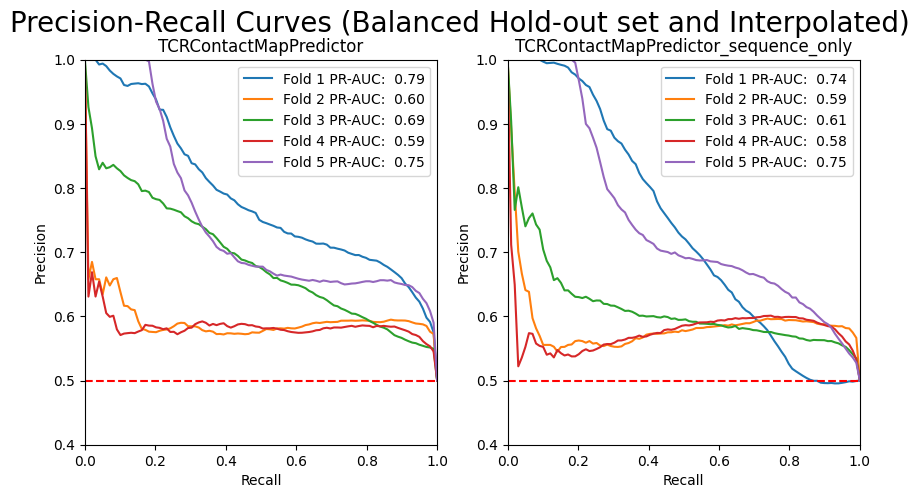

In [30]:
model_groups = pr_results_balanced.groupby('model_name')

fig, axes = plt.subplots(1, len(model_groups), figsize=(10, 5))

fig.suptitle('Precision-Recall Curves (Balanced Hold-out set and Interpolated)', fontsize=20)

for i, (model_name, model_group) in enumerate(model_groups):
    for fold, fold_group in model_group.groupby('fold'):
        pr_auc = fold_group['pr_auc'].to_numpy()[0]

        axes[i].plot(recall_interp, precision_interp[model_name][fold], label=f'Fold {fold} PR-AUC: {pr_auc: .2f}')

    axes[i].set_title(model_name)
    axes[i].plot([0, 1], [0.5, 0.5], 'r--')
    axes[i].set_xlabel('Recall')
    axes[i].set_ylabel('Precision')
    axes[i].set_xlim([0, 1])
    axes[i].set_ylim([0.4, 1])
    axes[i].legend()

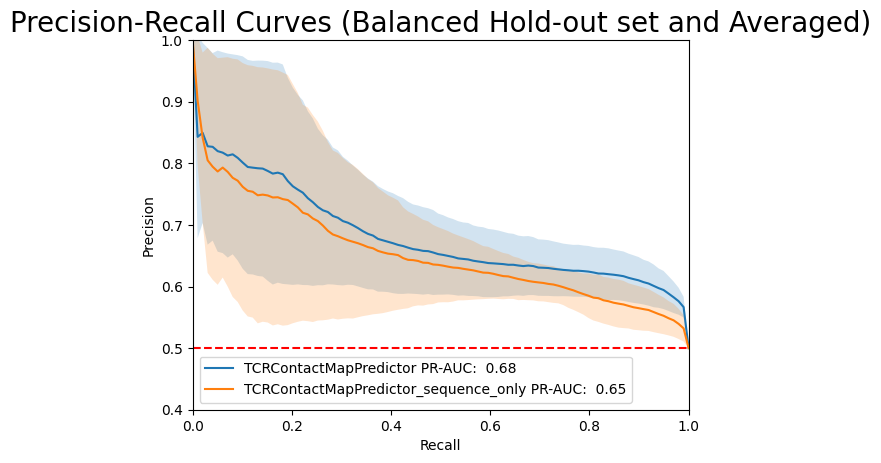

In [31]:
plt.title('Precision-Recall Curves (Balanced Hold-out set and Averaged)', fontsize=20)

for model_name, _ in pr_results_balanced.groupby('model_name'):
    precision_mean = np.mean(np.array(list(precision_interp[model_name].values())).T, axis=1)
    precision_std = np.std(np.array(list(precision_interp[model_name].values())).T, axis=1)

    pr_auc = metrics.auc(recall_interp, precision_mean)

    plt.plot(recall_interp, precision_mean, label=f'{model_name} PR-AUC: {pr_auc: .2f}')
    plt.fill_between(recall_interp, precision_mean - precision_std, precision_mean + precision_std, alpha=0.2)

plt.plot([0, 1], [0.5, 0.5], 'r--')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0, 1])
plt.ylim([0.4, 1])
plt.legend()

plt.show()

## F1-Score

In [32]:
THRESHOLD = 0.5
predictions['prediction_binary'] = (predictions['prediction'] > THRESHOLD).apply(int)

In [33]:
f1_results = predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results.name = 'f1_score'
f1_results = f1_results.reset_index()

f1_results.pivot_table(index='fold', columns='model_name', values='f1_score')

model_name,TCRContactMapPredictor,TCRContactMapPredictor_sequence_only
fold,,
1,0.381910,0.411721
2,0.156820,0.164623
3,0.228008,0.197531
4,0.124459,0.133570
5,0.351738,0.352974


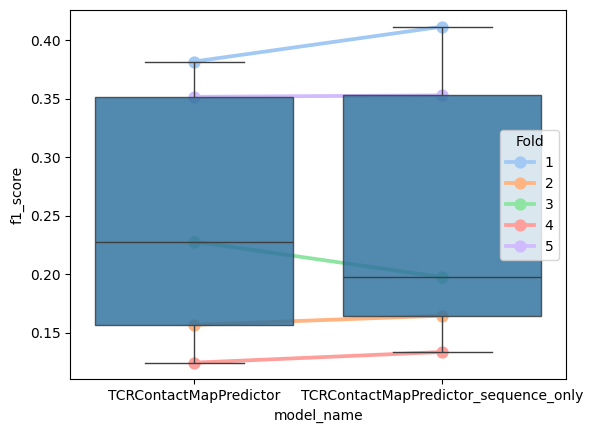

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.248587,0.228008,0.114747
TCRContactMapPredictor_sequence_only,0.252083,0.197531,0.122815


In [34]:
sns.pointplot(f1_results, x='model_name', y='f1_score', hue='fold', palette='pastel')
sns.boxplot(
    f1_results,
    x='model_name',
    y='f1_score',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

f1_results.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])

In [35]:
stats.wilcoxon(
    f1_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['f1_score'],
    f1_results.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['f1_score'],
    alternative='greater',
)

WilcoxonResult(statistic=5.0, pvalue=0.78125)

### Balancing classes

In [36]:
balanced_predictions['prediction_binary'] = (balanced_predictions['prediction'] > THRESHOLD).apply(int)

In [37]:
f1_results_balanced = balanced_predictions.groupby(['model_name', 'fold']).apply(
    lambda row: metrics.f1_score(row['label'], row['prediction_binary']),
    include_groups=False,
)
f1_results_balanced.name = 'f1_score'
f1_results_balanced = f1_results_balanced.reset_index()

f1_results_balanced.pivot_table(index='fold', columns='model_name', values='f1_score')

model_name,TCRContactMapPredictor,TCRContactMapPredictor_sequence_only
fold,,
1,0.442157,0.479860
2,0.195519,0.224005
3,0.260067,0.244222
4,0.148413,0.172849
5,0.401200,0.416721


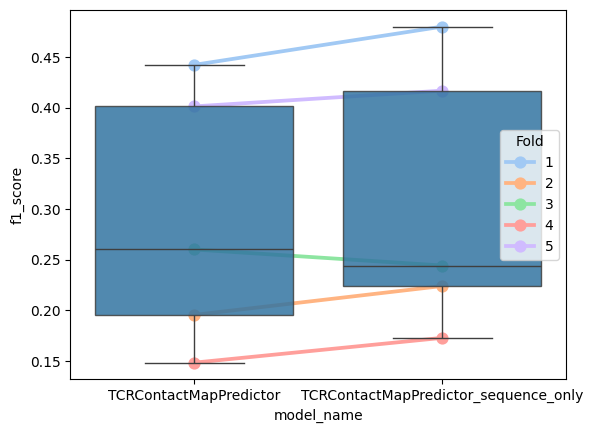

,mean,median,std
model_name,,,
TCRContactMapPredictor,0.289471,0.260067,0.127853
TCRContactMapPredictor_sequence_only,0.307531,0.244222,0.132988


In [38]:
sns.pointplot(f1_results_balanced, x='model_name', y='f1_score', hue='fold', palette='pastel')
sns.boxplot(
    f1_results_balanced,
    x='model_name',
    y='f1_score',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')
plt.show()

f1_results_balanced.groupby('model_name')['f1_score'].agg(['mean', 'median', 'std'])

In [39]:
stats.wilcoxon(
    f1_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['f1_score'],
    f1_results_balanced.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")['f1_score'],
    alternative='greater',
)

WilcoxonResult(statistic=2.0, pvalue=0.9375)

## Comparison of prediction results to mimimum distance between the peptides and the training set

In [40]:
amino_acid_olcs = np.array(sorted(IUPACData.protein_letters_3to1.values()))
amino_acid_olcs

array(['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P',
       'Q', 'R', 'S', 'T', 'V', 'W', 'Y'], dtype='<U1')

In [41]:
peptides_aa = np.array(
    [
        ''.join([amino_acid_olcs[one_hot.astype(bool)][0] for one_hot in peptide if np.sum(one_hot) > 0])
        for peptide in peptides
    ]
)

In [42]:
predictions['peptide_sequence'] = predictions['index'].map(lambda idx: peptides_aa[idx])

In [43]:
with open('data/interim/peptides.txt') as fh:
    peptide_key = np.array(fh.read().rstrip().split('\n'))

peptide_distances = np.loadtxt('data/interim/peptide_distances.txt', dtype=int)

In [44]:
# TODO think about how to handle peptides that have been cropped...


def get_minimum_peptide_distance(peptide_sequence: str, fold: int) -> int:
    if peptide_sequence not in peptide_key:
        return np.nan

    training_peptides = peptides_aa[folds != fold]
    training_key_idxs = np.where(np.isin(peptide_key, training_peptides))[0]
    peptide_index = np.where(peptide_sequence == peptide_key)[0][0]

    return np.min(peptide_distances[peptide_index][training_key_idxs])

In [45]:
peptide_folds = predictions[['peptide_sequence', 'fold']].drop_duplicates()
peptide_folds['min_peptide_distance'] = peptide_folds.apply(
    lambda row: get_minimum_peptide_distance(row.peptide_sequence, row.fold),
    axis=1,
)

In [46]:
predictions = predictions.merge(peptide_folds, how='left', on=['peptide_sequence', 'fold'])

<Axes: ylabel='Frequency'>

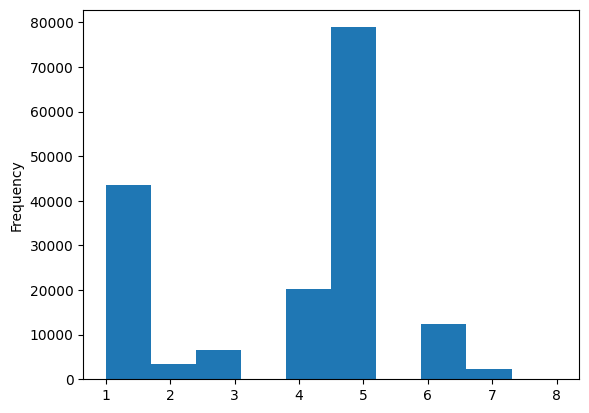

In [47]:
predictions['min_peptide_distance'].plot.hist()

In [48]:
peptide_distance_roc_aucs = predictions.groupby(['model_name', 'fold', 'min_peptide_distance']).apply(
    lambda group: metrics.roc_auc_score(group['label'], group['prediction']),
    include_groups=False,
)
peptide_distance_roc_aucs.name = 'roc_auc'

peptide_distance_roc_aucs = peptide_distance_roc_aucs.reset_index()

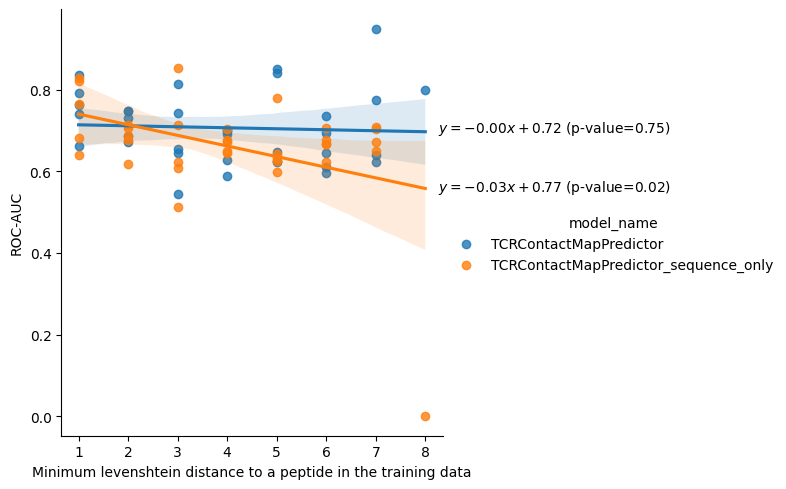

In [49]:
sns.lmplot(peptide_distance_roc_aucs, x='min_peptide_distance', y='roc_auc', hue='model_name')

for model_name in peptide_distance_roc_aucs['model_name'].unique():
    subset = peptide_distance_roc_aucs[peptide_distance_roc_aucs['model_name'] == model_name]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'$y = {slope:.2f}x + {intercept:.2f}$ (p-value={p_value:.2f})'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [50]:
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs.groupby(['model_name', 'fold']).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_lines.name = 'line'
peptide_distance_roc_aucs_lines = peptide_distance_roc_aucs_lines.reset_index()

peptide_distance_roc_aucs_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_lines['line'].apply(pd.Series)
)

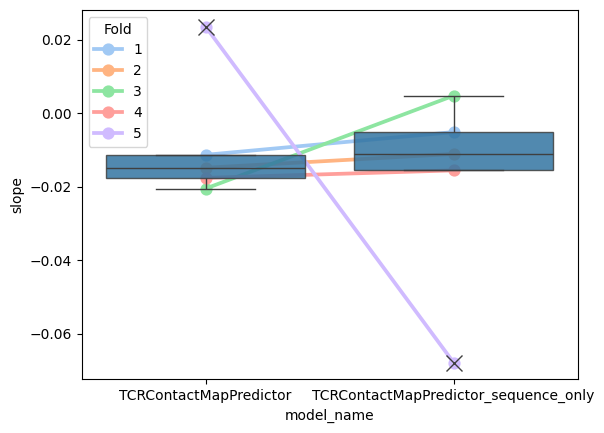

,mean,median,std
model_name,,,
TCRContactMapPredictor,-0.008160,-0.014859,0.018046
TCRContactMapPredictor_sequence_only,-0.018994,-0.011103,0.028381


In [51]:
sns.pointplot(peptide_distance_roc_aucs_lines, x='model_name', y='slope', hue='fold', palette='pastel')
sns.boxplot(
    peptide_distance_roc_aucs_lines,
    x='model_name',
    y='slope',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

peptide_distance_roc_aucs_lines.groupby('model_name')['slope'].agg(['mean', 'median', 'std'])

In [52]:
stats.wilcoxon(
    peptide_distance_roc_aucs_lines.sort_values('fold').query("model_name == 'TCRContactMapPredictor'")['slope'],
    peptide_distance_roc_aucs_lines.sort_values('fold').query("model_name == 'TCRContactMapPredictor_sequence_only'")[
        'slope'
    ],
    alternative='greater',
)

WilcoxonResult(statistic=5.0, pvalue=0.78125)

Removing outlier to see the effect...

In [53]:
peptide_distance_roc_aucs.sort_values('roc_auc')

,model_name,fold,min_peptide_distance,roc_auc
69,TCRContactMapPredictor_sequence_only,5,8.0,0.000000
37,TCRContactMapPredictor_sequence_only,1,3.0,0.512242
2,TCRContactMapPredictor,1,3.0,0.545543
30,TCRContactMapPredictor,5,4.0,0.587905
25,TCRContactMapPredictor,4,6.0,0.595092
...,...,...,...,...
20,TCRContactMapPredictor,4,1.0,0.835640
4,TCRContactMapPredictor,1,5.0,0.840847
31,TCRContactMapPredictor,5,5.0,0.850944
44,TCRContactMapPredictor_sequence_only,2,3.0,0.854438


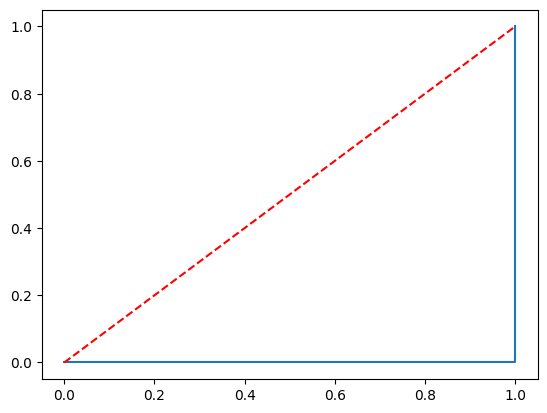

In [54]:
worst_fold = predictions.query(
    "model_name == 'TCRContactMapPredictor_sequence_only' and fold == 5 and min_peptide_distance == 8.0"
)
fpr, tpr, thresholds = metrics.roc_curve(worst_fold['label'], worst_fold['prediction'])

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--')

plt.show()

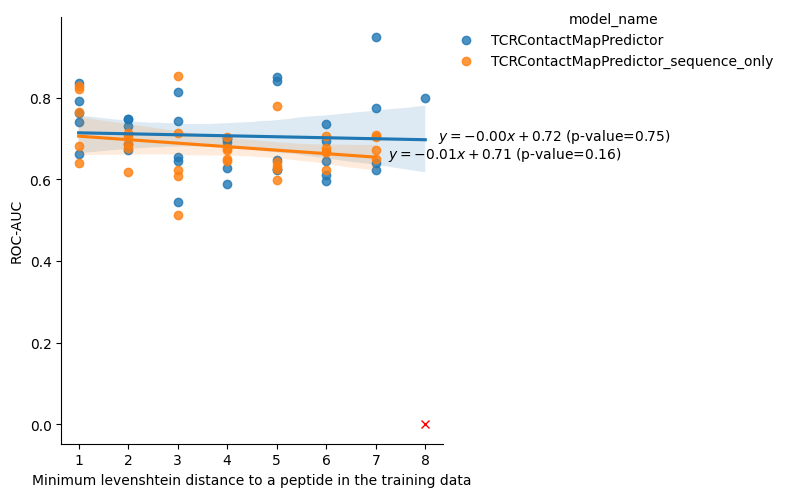

In [55]:
peptide_distance_roc_aucs_remove_outlier = peptide_distance_roc_aucs.query(
    "not (model_name == 'TCRContactMapPredictor_sequence_only' and fold == 5 and min_peptide_distance == 8.0)"
)

peptide_distance_roc_aucs_outlier = peptide_distance_roc_aucs.query(
    "model_name == 'TCRContactMapPredictor_sequence_only' and fold == 5 and min_peptide_distance == 8.0"
)

ax = sns.lmplot(peptide_distance_roc_aucs_remove_outlier, x='min_peptide_distance', y='roc_auc', hue='model_name')

for model_name in peptide_distance_roc_aucs_remove_outlier['model_name'].unique():
    subset = peptide_distance_roc_aucs_remove_outlier[
        peptide_distance_roc_aucs_remove_outlier['model_name'] == model_name
    ]
    slope, intercept, r_value, p_value, std_err = stats.linregress(subset['min_peptide_distance'], subset['roc_auc'])

    equation = f'$y = {slope:.2f}x + {intercept:.2f}$ (p-value={p_value:.2f})'

    x_pos = subset['min_peptide_distance'].max() + 0.25
    y_pos = slope * x_pos + intercept

    plt.text(x_pos, y_pos, equation, color='black')

plt.plot(peptide_distance_roc_aucs_outlier['min_peptide_distance'], peptide_distance_roc_aucs_outlier['roc_auc'], 'rx')

sns.move_legend(ax, 'upper right')
plt.xlabel('Minimum levenshtein distance to a peptide in the training data')
plt.ylabel('ROC-AUC')

plt.show()

In [56]:
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier.groupby(
    ['model_name', 'fold'],
).apply(
    lambda group: stats.linregress(group['min_peptide_distance'], group['roc_auc']),
    include_groups=False,
)

peptide_distance_roc_aucs_remove_outlier_lines.name = 'line'
peptide_distance_roc_aucs_remove_outlier_lines = peptide_distance_roc_aucs_remove_outlier_lines.reset_index()

peptide_distance_roc_aucs_remove_outlier_lines[['slope', 'intercept', 'r_value', 'p_value', 'std_err']] = (
    peptide_distance_roc_aucs_remove_outlier_lines['line'].apply(pd.Series)
)

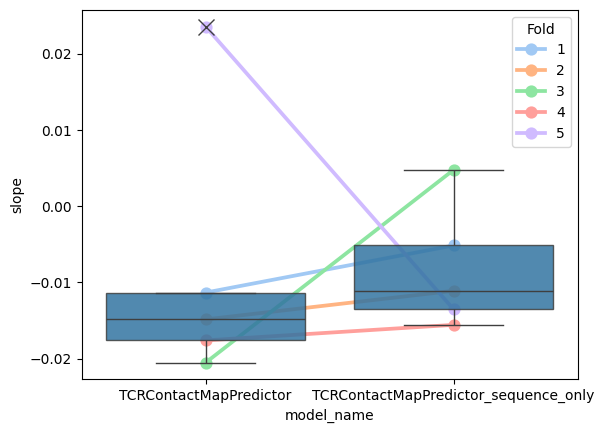

,mean,median,std
model_name,,,
TCRContactMapPredictor,-0.008160,-0.014859,0.018046
TCRContactMapPredictor_sequence_only,-0.008123,-0.011103,0.008196


In [57]:
sns.pointplot(peptide_distance_roc_aucs_remove_outlier_lines, x='model_name', y='slope', hue='fold', palette='pastel')
sns.boxplot(
    peptide_distance_roc_aucs_remove_outlier_lines,
    x='model_name',
    y='slope',
    boxprops={'alpha': 0.85},
    flierprops={'marker': 'x', 'markersize': 12},
)

plt.legend(title='Fold')

plt.show()

peptide_distance_roc_aucs_remove_outlier_lines.groupby('model_name')['slope'].agg(['mean', 'median', 'std'])

In [58]:
stats.wilcoxon(
    peptide_distance_roc_aucs_remove_outlier_lines.sort_values('fold').query(
        "model_name == 'TCRContactMapPredictor'",
    )['slope'],
    peptide_distance_roc_aucs_remove_outlier_lines.sort_values('fold').query(
        "model_name == 'TCRContactMapPredictor_sequence_only'",
    )['slope'],
    alternative='greater',
)

WilcoxonResult(statistic=5.0, pvalue=0.78125)